# Induced-EQ Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [ ]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib import cycler
import matplotlib.pyplot as plt
import torch


def apply_publication_style():
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Nimbus Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'stix',
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'lines.linewidth': 1.1,
        'lines.markersize': 4,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,
        'grid.alpha': 0.25,
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.unicode_minus': False,
        'axes.prop_cycle': cycler(color=[
            '#4E79A7', '#F28E2B', '#59A14F', '#E15759',
            '#76B7B2', '#B07AA1', '#EDC948', '#9C755F', '#BAB0AC',
        ]),
    })


def save_pub_figure(fig, output_path, dpi=300, file_format='pdf'):
    output_path = Path(output_path)
    file_format = str(file_format).lower().lstrip('.')
    if file_format not in {'pdf', 'png'}:
        raise ValueError("file_format must be 'pdf' or 'png'")
    target_path = output_path.with_suffix(f'.{file_format}')
    save_kwargs = {'bbox_inches': 'tight'}
    if file_format == 'png':
        save_kwargs['dpi'] = dpi
    fig.savefig(target_path, format=file_format, **save_kwargs)


apply_publication_style()


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs
import src.utils.catalog_tests as catalog_tests
from src.models.tpp import etas, recurrent
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.visualization import visualize_sequence, visualize_trajectories, plot_intensity

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration

In [2]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints/rtpp_20260402-160131'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

# Optional: replace current background model with another checkpoint's background model.
USE_ALT_BG_MODEL = False
ALT_BG_CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints' / 'etas_20251221-224107' / 'best_model_1.pth'

USE_TORCH_COMPILE = True
MODEL_MM = 6.5  # set to None to skip overriding model.M_m

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/rtpp_20260402-160131/best_model_1.pth


## 3) Load Model and Catalog

In [3]:
def unwrap_model(m):
    return m._orig_mod if hasattr(m, '_orig_mod') else m


model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
model = unwrap_model(model)

if USE_ALT_BG_MODEL:
    alt_model, _ = load_and_prepare_model(
        checkpoint_path=ALT_BG_CHECKPOINT_PATH,
        device=DEVICE,
        compile=False,
    )
    alt_model = unwrap_model(alt_model)
    if getattr(alt_model, 'bg_model', None) is not None:
        model.bg_model = alt_model.bg_model
    del alt_model

if MODEL_MM is not None and hasattr(model, 'M_m'):
    model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

if getattr(model, 'bg_model', None) is not None:
    print(f'background scale: {model.bg_model._scale}')

if hasattr(model, 'print_params'):
    model.print_params()

background scale: 1065.9818115234375


Using catalog registry name: PNR_1z-Standard


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

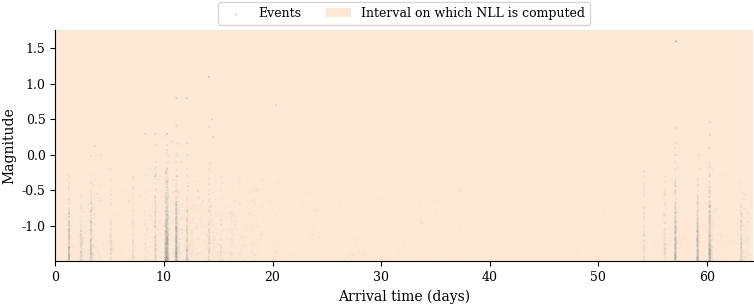

In [4]:
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
if  hasattr(metadata, 'start_ts') and hasattr(metadata, 'val_start_ts') and hasattr(metadata, 'test_start_ts') and hasattr(metadata, 'freq'):
    start_ts = pd.to_datetime(metadata['start_ts'])
    val_start_ts = pd.to_datetime(metadata['val_start_ts'])
    test_start_ts = pd.to_datetime(metadata['test_start_ts'])
    freq_td = pd.to_timedelta(metadata['freq'])

    print(f'Model: {args.model} | Dataset: {args.dataset}')
    print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
    print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]

visualize_sequence(full_seq, show_nll=True)

In [5]:
model.bg_model.stochastic_eval = False

In [6]:
catalog_ds.metadata

{'name': 'PNR_1z',
 'freq': '1D',
 'mag_roundoff_error': 0.01,
 'mag_completeness': -1.5,
 'region': '1z',
 'start_ts': Timestamp('2018-10-15 08:00:00'),
 'end_ts': Timestamp('2018-12-18 13:00:00'),
 'train_start_ts': Timestamp('2018-10-22 00:00:00'),
 'val_start_ts': Timestamp('2018-11-22 00:00:00'),
 'test_start_ts': Timestamp('2018-12-14 00:00:00')}

## 4) Batch and Intensity Diagnostics

In [7]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)

SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
batch = sequence_to_batch(seq, DEVICE)

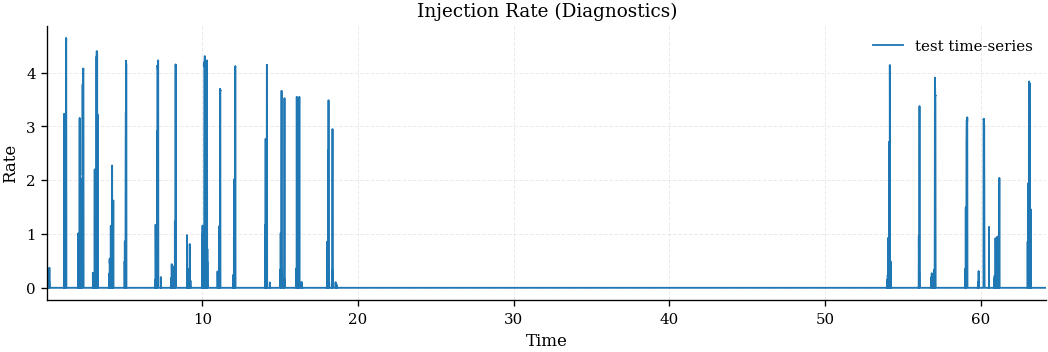

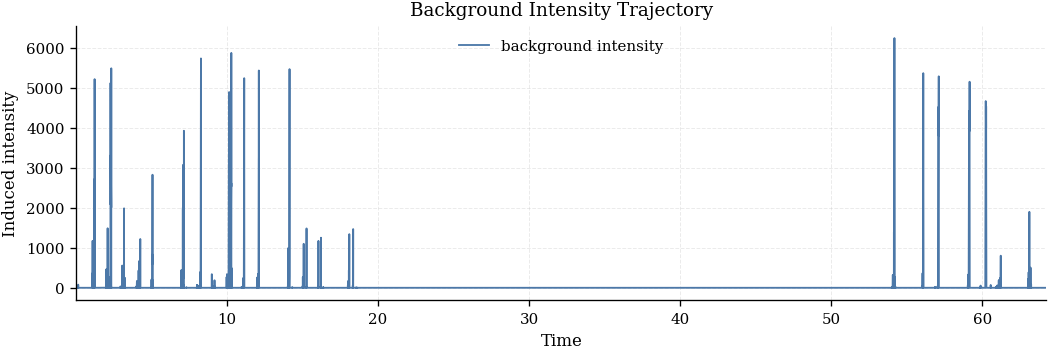

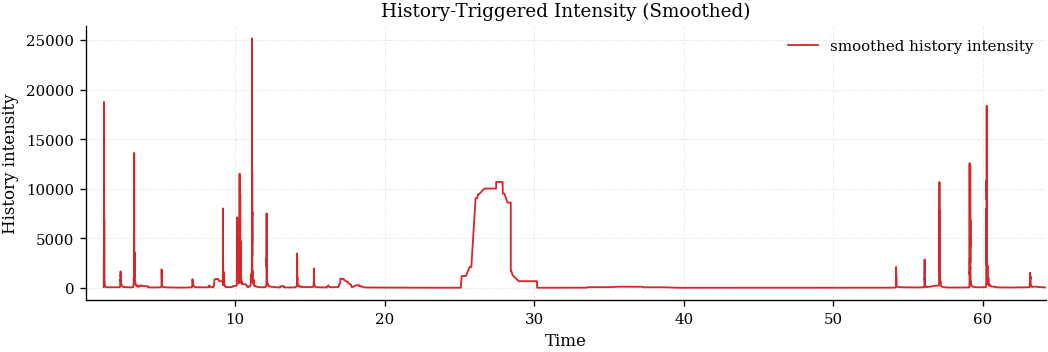

count(h_intensity > 1000): 3149


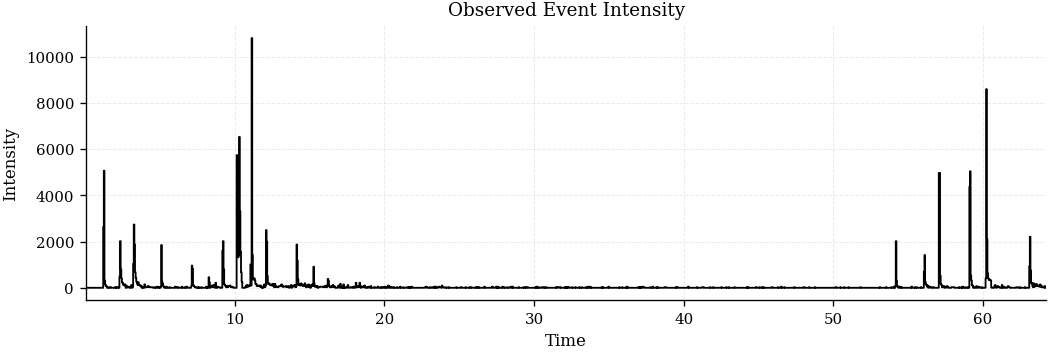

In [8]:
diag_times = batch.time_series_times.reshape(-1)
if diag_times.numel() > 0:
    diag_start = float(diag_times.min().item())
    diag_end = float(diag_times.max().item())
else:
    diag_start = float(seq.t_start)
    diag_end = float(seq.t_end)

diag_colors = {
    'series': '#1f77b4',
    'bg': '#4c78a8',
    'hist': '#d62728',
    'hawkes': '#ff7f0e',
}

def _apply_diag_axis(ax, xlabel='Time', ylabel=None, title=None):
    ax.set_xlim(diag_start, diag_end)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(
    batch.time_series_times.squeeze().detach().cpu().numpy(),
    batch.time_series.squeeze().detach().cpu().numpy(),
    linewidth=1.1,
    color=diag_colors['series'],
    label='test time-series',
)
_apply_diag_axis(ax, ylabel='Rate', title='Injection Rate (Diagnostics)')
ax.legend(frameon=False)
fig.tight_layout()
save_pub_figure(fig, CHECKPOINT_DIR / 'diagnostic_injection_rate.png')
plt.show()

if getattr(model, 'bg_model', None) is not None:
    f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.time_series_times.squeeze().detach().cpu().numpy(),
        f_intensity_trajectory.squeeze().detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['bg'],
        label='background intensity',
    )
    _apply_diag_axis(ax, ylabel='Induced intensity', title='Background Intensity Trajectory')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'induced_intensity.png')
    plt.show()

if isinstance(model, recurrent.RecurrentTPP):
    context = model.get_context(batch)
    inter_time_dist = model.get_inter_time_dist(context)
    log_h = inter_time_dist.log_hazard(batch.inter_times.clamp_min(1e-10))
    h_intensity = torch.exp(log_h)
    h_intensity = torch.where(h_intensity > 500000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

    window = 20
    arrival_times_np = batch.arrival_times.detach().cpu().numpy().ravel()
    raw_np = h_intensity.detach().cpu().numpy().ravel()
    smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        arrival_times_np,
        smoothed,
        linewidth=1.1,
        color=diag_colors['hist'],
        label='smoothed history intensity',
    )
    _apply_diag_axis(ax, ylabel='History intensity', title='History-Triggered Intensity (Smoothed)')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'history_intensity_smoothed.png')
    plt.show()

    print('count(h_intensity > 1000):', int((h_intensity > 1000).sum().item()))
elif isinstance(model, etas.ETAS):
    h_intensity = model.h_intensity(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
        h_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['hawkes'],
    )
    _apply_diag_axis(ax, ylabel='Hawkes intensity', title='Hawkes Intensity')
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'hawkes_intensity.png')
    plt.show()

fig, ax = plt.subplots(figsize=(9, 3.2))
plot_intensity(seq, dt=1/24, ax=ax, T0=diag_start, T=diag_end)
_apply_diag_axis(ax, ylabel='Intensity', title='Observed Event Intensity')
fig.tight_layout()
save_pub_figure(fig, CHECKPOINT_DIR / 'observed_event_intensity.png')
plt.show()


## 5) Single-Window Forecast

In [34]:
# Single forecast window settings
T_FORECAST = 8
FORECAST_DURATION =1
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = 1000

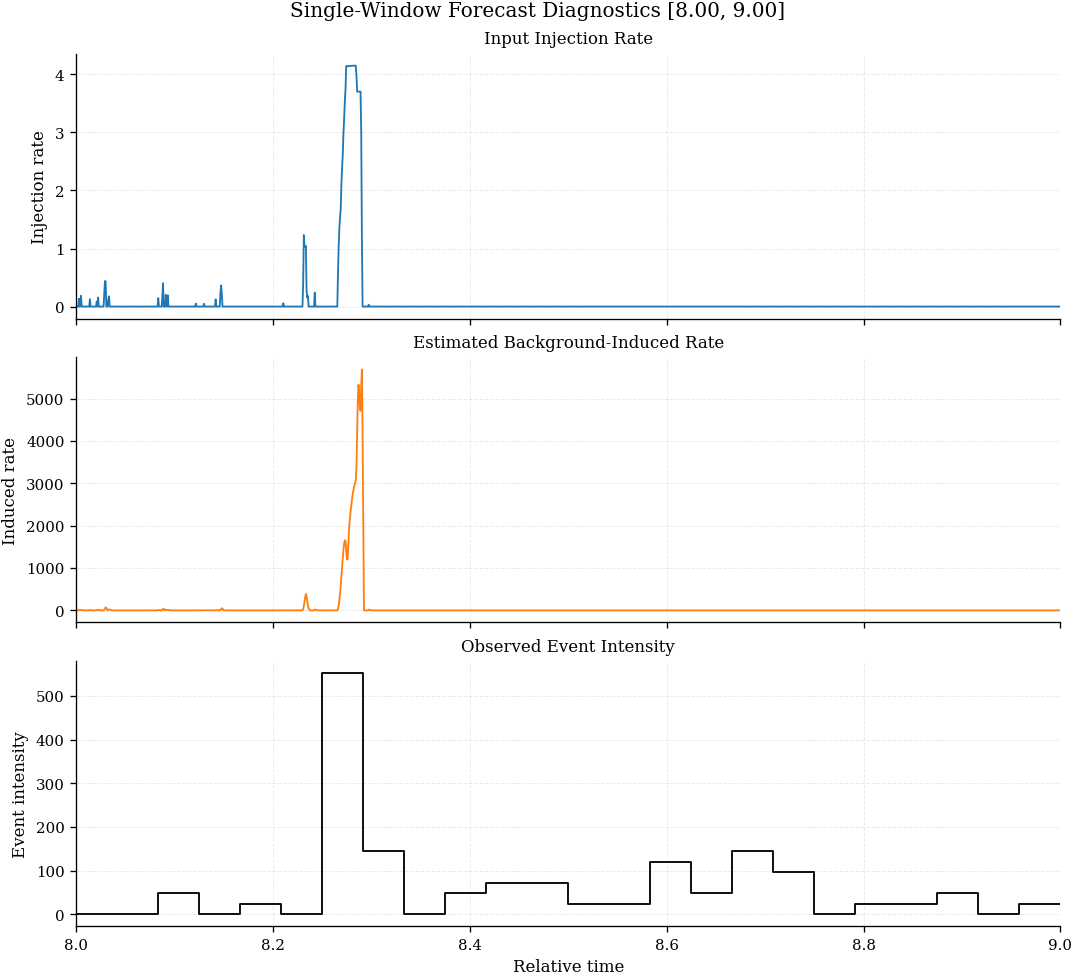

Background forecast count in [8, 9]: 67.16656494140625
Observed events in window: 64


In [35]:
past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)

mask_future = (seq.time_series_times >= window_start) & (seq.time_series_times < window_end)
future_time_series = seq.time_series[mask_future]
future_time_series_times = seq.time_series_times[mask_future]

window_colors = {
    'inj': '#1f77b4',
    'bg': '#ff7f0e',
    'obs': '#2ca02c',
}

def _apply_window_axis(ax, ylabel=None, title=None, show_xlabel=False):
    ax.set_xlim(window_start, window_end)
    if show_xlabel:
        ax.set_xlabel('Relative time')
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

if getattr(model, 'bg_model', None) is not None:
    model.bg_model.cache_batch(
        time_series=seq.time_series.unsqueeze(0),
        time_series_times=seq.time_series_times.unsqueeze(0),
    )
    times_all = seq.time_series_times
    window_mask = (times_all >= window_start) & (times_all < window_end)
    window_times = times_all[window_mask]
    f_intensity = model.bg_model.intensity(
        ts_batch=model.bg_model.ts_batch_cache,
        t_query=window_times.unsqueeze(0),
    )

    fig, (ax_inj, ax_bg, ax_obs) = plt.subplots(
        3, 1, figsize=(9, 8.2), sharex=True, constrained_layout=True
    )
    fig.suptitle(f'Single-Window Forecast Diagnostics [{window_start:.2f}, {window_end:.2f}]', fontsize=12)

    ax_inj.plot(
        future_time_series_times.detach().cpu().numpy(),
        future_time_series.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['inj'],
    )
    _apply_window_axis(
        ax_inj,
        ylabel='Injection rate',
        title='Input Injection Rate',
    )

    ax_bg.plot(
        window_times.detach().cpu().numpy(),
        f_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['bg'],
    )
    _apply_window_axis(
        ax_bg,
        ylabel='Induced rate',
        title='Estimated Background-Induced Rate',
    )

    plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel='Event intensity',
        title='Observed Event Intensity',
        show_xlabel=True,
    )

    save_pub_figure(fig, CHECKPOINT_DIR / 'single_window_forecast_diagnostics.png')
    plt.show()

    bg_count = model.bg_model.forecast_count(window_start, window_end)
    print(f'Background forecast count in [{window_start:g}, {window_end:g}]: {bg_count}')
else:
    fig, (ax_inj, ax_obs) = plt.subplots(
        2, 1, figsize=(9, 5.8), sharex=True, constrained_layout=True
    )
    fig.suptitle(f'Single-Window Forecast Diagnostics [{window_start:.2f}, {window_end:.2f}]', fontsize=12)

    ax_inj.plot(
        future_time_series_times.detach().cpu().numpy(),
        future_time_series.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['inj'],
    )
    _apply_window_axis(
        ax_inj,
        ylabel='Injection rate',
        title='Input Injection Rate',
    )

    plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel='Event intensity',
        title='Observed Event Intensity',
        show_xlabel=True,
    )

    save_pub_figure(fig, CHECKPOINT_DIR / 'single_window_forecast_diagnostics.png')
    plt.show()

print('Observed events in window:', len(observed_seq))


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Total forecasts: 1000
Forecasts containing zero inter_times: 1


(<Figure size 1500x450 with 3 Axes>,
 (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, xlabel='Days since 2018-10-15', ylabel='Magnitude'>,
  <Axes: title={'center': 'Forecast counts'}, xlabel='Frequency', ylabel='Event count in window'>,
  <Axes: ylabel='Cumulative count'>))

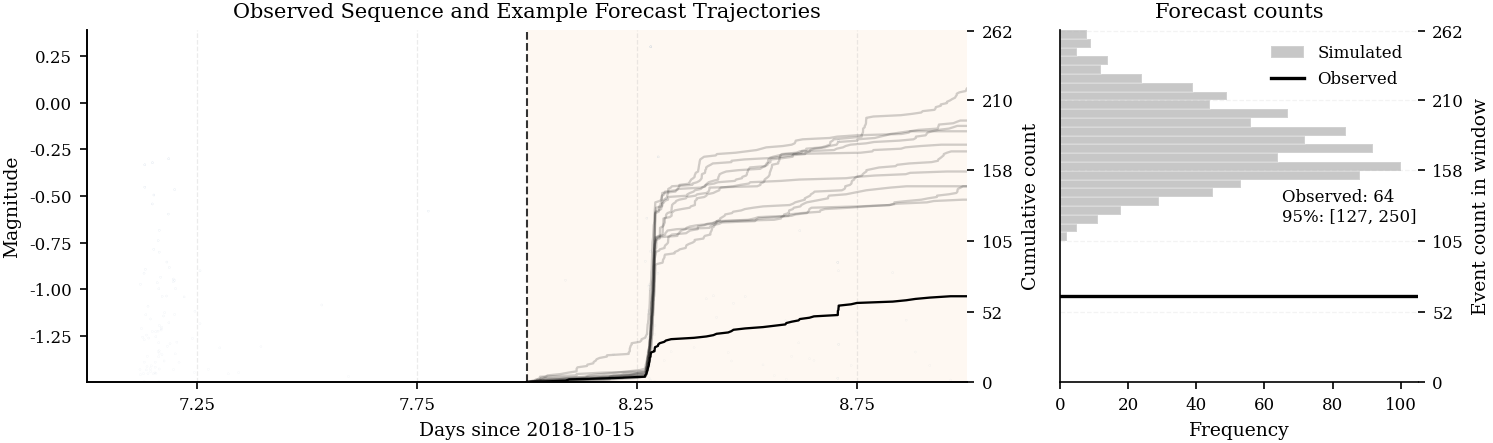

In [36]:
def generate_forecasts(model, past_seq, duration, num_samples, samples_per_batch, seed=3):
    return sample_tpp_forecasts(
        model,
        past_seq,
        duration=duration,
        num_samples=int(num_samples),
        samples_per_batch=samples_per_batch,
        seed=seed,
    )


past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq
all_forecasts = generate_forecasts(
    model=model,
    past_seq=past_seq_device,
    duration=FORECAST_DURATION,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    seed=3,
)

zero_indices = []
for idx, fc in enumerate(all_forecasts):
    inter_times = torch.as_tensor(fc.inter_times).cpu()
    if (inter_times == 0).any():
        zero_indices.append(idx)

print('Total forecasts:', len(all_forecasts))
print('Forecasts containing zero inter_times:', len(zero_indices))
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
visualize_trajectories(
    seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / 'all_forecasts.pdf',
    figsize=(10, 3),
    xlabel='Days since ' + date_strs,
    reset_t_nll_to_end=True,
)

def generate_forecasts(model, past_seq, duration, num_samples, samples_per_batch, seed=3):
    return sample_tpp_forecasts(
        model,
        past_seq,
        duration=duration,
        num_samples=int(num_samples),
        samples_per_batch=samples_per_batch,
        seed=seed,
    )


past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq
all_forecasts = generate_forecasts(
    model=model,
    past_seq=past_seq_device,
    duration=FORECAST_DURATION,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    seed=3,
)

zero_indices = []
for idx, fc in enumerate(all_forecasts):
    inter_times = torch.as_tensor(fc.inter_times).cpu()
    if (inter_times == 0).any():
        zero_indices.append(idx)

print('Total forecasts:', len(all_forecasts))
print('Forecasts containing zero inter_times:', len(zero_indices))
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
visualize_trajectories(
    seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / 'all_forecasts.pdf',
    figsize=(10, 3),
    xlabel='Days since ' + date_strs,
    reset_t_nll_to_end=True,
)

## 6) RMSE, N-Test, and M-Test

RMSE: 119.875056


Empty forecasts: 0
Forecast mag range (non-empty only): (2.172945261001587, -1.4999938011169434)
Observed mag range: (0.30000001192092896, -1.496000051498413)


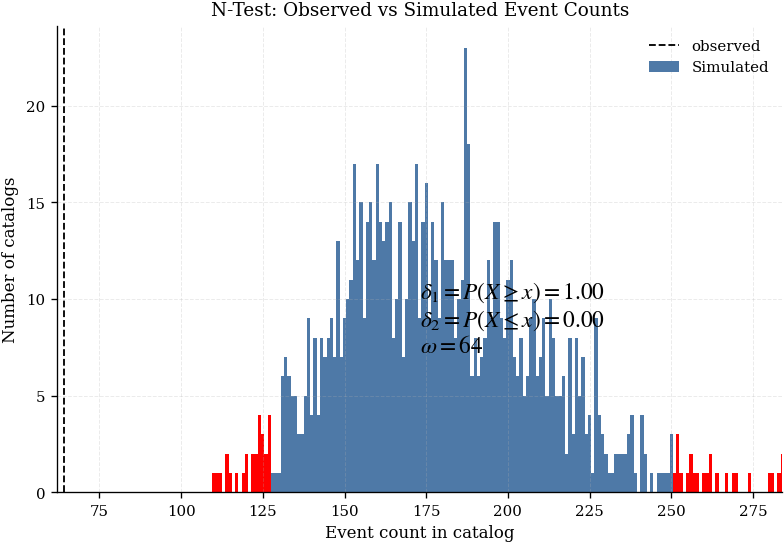

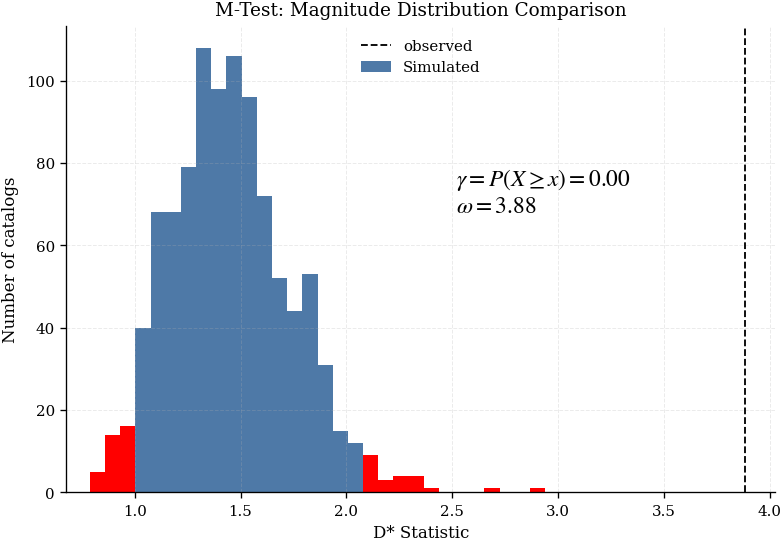

In [37]:
forecast_counts = np.array([len(fc) for fc in all_forecasts], dtype=float)
observed_count = len(observed_seq)
rmse = float(np.sqrt(np.mean((forecast_counts - observed_count) ** 2)))
print(f'RMSE: {rmse:.6f}')

def _style_current_figure(title=None):
    fig = plt.gcf()
    if title is not None and fig.axes:
        fig.axes[0].set_title(title)
    for ax in fig.axes:
        ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        legend = ax.get_legend()
        if legend is not None:
            legend.set_frame_on(False)
    fig.tight_layout()
    return fig

number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=observed_count,
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
number_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
fig_n = _style_current_figure('N-Test: Observed vs Simulated Event Counts')
save_pub_figure(fig_n, CHECKPOINT_DIR / 'n_test.pdf')

non_empty_forecasts = [fc for fc in all_forecasts if len(fc) > 0]
empty_forecast_count = len(all_forecasts) - len(non_empty_forecasts)
print('Empty forecasts:', empty_forecast_count)

if non_empty_forecasts:
    mag_max = [fc.mag.max().item() for fc in non_empty_forecasts]
    mag_min = [fc.mag.min().item() for fc in non_empty_forecasts]
    print('Forecast mag range (non-empty only):', (max(mag_max), min(mag_min)))
else:
    print('Forecast mag range: no non-empty forecasts')

if len(observed_seq) > 0:
    print('Observed mag range:', (observed_seq.mag.max().item(), observed_seq.mag.min().item()))
else:
    print('Observed mag range: observed sequence is empty')

config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01,
}

if non_empty_forecasts:
    # quick check distribution API on one non-empty forecast
    _ = catalog_tests.compute_magnitude_distribution(non_empty_forecasts[0].mag.cpu().numpy(), **config_dict)

get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
 )

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
magnitude_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
fig_m = _style_current_figure('M-Test: Magnitude Distribution Comparison')
save_pub_figure(fig_m, CHECKPOINT_DIR / 'm_test.pdf')

## 7) Sliding-Window Forecast Evaluation

In [38]:
# Sliding-window settings
SLIDING_DURATION = 12
SLIDING_STEP = 12
SLIDING_QUANTILES = (2.5, 97.5)
RUN_SLIDING_WINDOW_FORECAST = True  # set to True to run the sliding window forecast, which can be time-consuming depending on settings
SLIDING_VIEW_MODE = 'zoomed'  # 'zoomed' | 'full' | 'auto'


In [ ]:
import matplotlib.dates as mdates
from matplotlib import ticker as mticker

PLOT_COLORS = {
    'true': '#1f77b4',
    'mean': '#ff7f0e',
    'pi': '#4c78a8',
    'err': '#d62728',
    'covered': '#2ca02c',
    'below': '#e45756',
    'above': '#9467bd',
}


def run_sliding_window_forecast(
    model,
    seq,
    device,
    duration=12,
    slide_step=12,
    quantiles=(2.5, 97.5),
    samples_per_batch=1000,
):
    start = float(seq.arrival_times[0].item())
    end = float(seq.arrival_times[-1].item())

    t_forecast_list = np.arange(start + duration, end - duration, slide_step)
    print(f't_forecast_list: {t_forecast_list}')

    counts_list = []
    q_list = []
    mean_list = []

    model.eval()

    for t_forecast in t_forecast_list:
        t_end = min(t_forecast + duration, end)

        past_seq = seq.get_subsequence(0, t_forecast, reset_t_nll_to_end=True).to(device)
        observed_seq = seq.get_subsequence(t_forecast, t_end, reset_t_nll_to_end=True).to(device)

        forecasts = model.sample(
            batch_size=samples_per_batch,
            duration=(t_end - t_forecast),
            past_seq=past_seq,
            return_sequences=True,
        )
        fc_counts = np.fromiter((len(fc) for fc in forecasts), dtype=np.int32)

        q = np.percentile(fc_counts, quantiles)
        mean = float(fc_counts.mean())

        q_list.append(q)
        mean_list.append(mean)
        counts_list.append(len(observed_seq))

    return np.array(t_forecast_list), np.array(counts_list), np.array(q_list), np.array(mean_list)


def to_absolute_time_axis(rel_times, base_ts, freq_td):
    rel = np.asarray(rel_times, dtype=float).reshape(-1)
    delta = pd.to_timedelta(rel * freq_td.total_seconds(), unit='s')
    return pd.DatetimeIndex(pd.Timestamp(base_ts) + delta)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelrotation=0)


def style_axes(ax, xlabel='Forecast start date', ylabel=None, integer_y=False):
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if integer_y:
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))


def resolve_catalog_time_reference(catalog_ds):
    md = getattr(catalog_ds, 'metadata', {})
    if isinstance(md, dict):
        start_val = md.get('start_ts')
        freq_val = md.get('freq')
    else:
        start_val = getattr(md, 'start_ts', None)
        freq_val = getattr(md, 'freq', None)

    if start_val is None or freq_val is None:
        raise KeyError("catalog_ds.metadata must contain 'start_ts' and 'freq'.")

    return pd.to_datetime(start_val), pd.to_timedelta(freq_val)


def compute_display_upper_cap(q_low, q_high, counts, mean, pct=80):
    q_ref = np.asarray(q_high, dtype=float).reshape(-1)
    robust_cap = float(np.nanpercentile(q_ref, pct))
    anchor = float(np.nanmax(np.concatenate([q_low.reshape(-1), counts.reshape(-1), mean.reshape(-1)])))
    return max(robust_cap, anchor * 1.10, 1.0)


def infer_step_timedelta(ts_index, fallback_td):
    ts_index = pd.DatetimeIndex(ts_index)
    fallback_td = pd.to_timedelta(fallback_td)
    if len(ts_index) >= 2:
        deltas = pd.Series(ts_index).diff().dropna()
        deltas = deltas[deltas > pd.Timedelta(0)]
        if not deltas.empty:
            return deltas.median()
    return fallback_td if fallback_td > pd.Timedelta(0) else pd.Timedelta(days=1)


def resolve_time_bounds(ts_index, fallback_td):
    ts_index = pd.DatetimeIndex(ts_index)
    step_td = infer_step_timedelta(ts_index, fallback_td)

    if len(ts_index) == 0:
        now = pd.Timestamp.today().normalize()
        return now, now + step_td, step_td

    left = ts_index.min() - step_td * 0.35
    right = ts_index.max() + step_td * 0.65
    if right <= left:
        right = left + step_td
    return left, right, step_td


def build_post_step(ts_index, values, step_td):
    ts_index = pd.DatetimeIndex(ts_index)
    values = np.asarray(values, dtype=float).reshape(-1)

    if len(ts_index) == 0:
        return ts_index, values
    if len(ts_index) == 1:
        ts_step = pd.DatetimeIndex([ts_index[0], ts_index[0] + step_td])
        v_step = np.array([values[0], values[0]], dtype=float)
        return ts_step, v_step

    ts_step = ts_index.append(pd.DatetimeIndex([ts_index[-1] + step_td]))
    v_step = np.r_[values, values[-1]]
    return ts_step, v_step


def resolve_view_mode(config_value, *, auto_use_zoom):
    mode = str(config_value).strip().lower()
    if mode not in {'zoomed', 'full', 'auto'}:
        print(f"Invalid SLIDING_VIEW_MODE={config_value!r}; fallback to 'auto'.")
        mode = 'auto'
    if mode == 'auto':
        return 'zoomed' if auto_use_zoom else 'full'
    return mode


if RUN_SLIDING_WINDOW_FORECAST:
    t_forecast_list, counts_list, q_list, mean_list = run_sliding_window_forecast(
        model=model,
        seq=seq,
        device=DEVICE,
        duration=SLIDING_DURATION,
        slide_step=SLIDING_STEP,
        quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
    )

    if len(t_forecast_list) == 0:
        print('No sliding windows available with current duration/step settings.')
    else:
        q_low, q_high = q_list[:, 0], q_list[:, 1]
        covered = (counts_list >= q_low) & (counts_list <= q_high)
        coverage = float(covered.mean())
        mae = float(np.mean(np.abs(counts_list - mean_list)))
        rmse = float(np.sqrt(np.mean((counts_list - mean_list) ** 2)))
        print(f'acceptance rate: {coverage:.2%}')

        base_start_ts, freq_td_local = resolve_catalog_time_reference(catalog_ds)
        seq_start_rel = float(getattr(seq, 't_start', 0.0))
        seq_start_ts = pd.Timestamp(base_start_ts) + pd.to_timedelta(
            seq_start_rel * freq_td_local.total_seconds(), unit='s'
        )
        t_forecast_ts = to_absolute_time_axis(t_forecast_list, seq_start_ts, freq_td_local)

        default_step_td = pd.to_timedelta(
            max(float(SLIDING_STEP), 1e-6) * freq_td_local.total_seconds(),
            unit='s',
        )
        plot_x_left, plot_x_right, inferred_step_td = resolve_time_bounds(
            t_forecast_ts,
            default_step_td,
        )

        # 1) Counts over time
        display_cap = compute_display_upper_cap(q_low, q_high, counts_list, mean_list, pct=80)
        base_bottom = min(0.0, float(np.nanmin(q_low)) * 1.05)
        zoom_top = display_cap * 1.05
        full_top = max(float(np.nanmax(q_high)) * 1.05, zoom_top)
        counts_mode = resolve_view_mode(SLIDING_VIEW_MODE, auto_use_zoom=(full_top > zoom_top * 1.8))

        if counts_mode == 'zoomed':
            q_high_plot = np.minimum(q_high, display_cap)
            clipped_mask = q_high > display_cap
            counts_ylim_top = zoom_top
            counts_title = 'Counts: true vs forecast (zoomed)'
            cap_note = f" | clipped={int(np.count_nonzero(clipped_mask))}" if np.any(clipped_mask) else ''
        else:
            q_high_plot = q_high
            clipped_mask = np.zeros_like(q_high, dtype=bool)
            counts_ylim_top = full_top
            counts_title = 'Counts: true vs forecast (full range)'
            cap_note = ''

        fig, ax = plt.subplots(figsize=(10.5, 4.4))
        ax.plot(
            t_forecast_ts,
            counts_list,
            label='true counts',
            color=PLOT_COLORS['true'],
            linewidth=1.1,
            marker='o',
            markersize=2.8,
            markerfacecolor='white',
            markeredgewidth=0.8,
        )
        ax.plot(
            t_forecast_ts,
            mean_list,
            label='forecast mean',
            color=PLOT_COLORS['mean'],
            linewidth=1.1,
            marker='o',
            markersize=2.8,
            markerfacecolor='white',
            markeredgewidth=0.8,
        )
        ax.fill_between(
            t_forecast_ts,
            q_low,
            q_high_plot,
            alpha=0.14,
            color=PLOT_COLORS['pi'],
            label='forecast PI (2.5-97.5)',
        )
        if np.any(clipped_mask):
            ax.scatter(
                t_forecast_ts[clipped_mask],
                np.full(int(clipped_mask.sum()), display_cap),
                marker='^',
                s=20,
                color=PLOT_COLORS['pi'],
                label='PI upper clipped (display)',
                zorder=4,
            )

        style_axes(ax, ylabel='count in next window', integer_y=True)
        format_time_axis(ax)
        ax.set_xlim(plot_x_left, plot_x_right)
        ax.set_ylim(base_bottom, counts_ylim_top)
        ax.set_title(counts_title)
        ax.text(
            0.01,
            0.02,
            f'Coverage: {coverage:.2%} | MAE: {mae:.2f} | RMSE: {rmse:.2f}{cap_note}',
            transform=ax.transAxes,
            va='bottom',
            ha='left',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )
        ax.legend(frameon=False, ncol=2, loc='upper left')
        fig.tight_layout()
        save_pub_figure(fig, CHECKPOINT_DIR / 'forecast_counts_over_time.png')
        plt.show()

        # 2) Error over time
        err = counts_list - mean_list
        bias = float(np.mean(err))
        err_abs = np.abs(err)
        err_zoom_lim = max(float(np.nanpercentile(err_abs, 80)) * 1.2, 1.0)
        err_full_lim = max(float(np.max(err_abs)) * 1.05, err_zoom_lim)
        error_mode = resolve_view_mode(SLIDING_VIEW_MODE, auto_use_zoom=(err_full_lim > err_zoom_lim * 1.8))

        clip_lim = err_zoom_lim if error_mode == 'zoomed' else None
        if clip_lim is None:
            err_plot = err
            clip_hi = np.zeros(err.shape, dtype=bool)
            clip_lo = np.zeros(err.shape, dtype=bool)
            err_title = 'Forecast error over time (full range)'
            err_ylim = err_full_lim
        else:
            err_plot = np.clip(err, -clip_lim, clip_lim)
            clip_hi = err > clip_lim
            clip_lo = err < -clip_lim
            err_title = 'Forecast error over time (zoomed)'
            err_ylim = clip_lim

        fig, ax = plt.subplots(figsize=(10.5, 3.8))
        ax.plot(
            t_forecast_ts,
            err_plot,
            label='true - mean',
            color=PLOT_COLORS['err'],
            linewidth=1.0,
            marker='o',
            markersize=2.6,
            markerfacecolor='white',
            markeredgewidth=0.8,
        )
        if clip_lim is not None and np.any(clip_hi):
            ax.scatter(
                t_forecast_ts[clip_hi],
                np.full(int(clip_hi.sum()), clip_lim),
                marker='^',
                s=20,
                color=PLOT_COLORS['err'],
                zorder=4,
            )
        if clip_lim is not None and np.any(clip_lo):
            ax.scatter(
                t_forecast_ts[clip_lo],
                np.full(int(clip_lo.sum()), -clip_lim),
                marker='v',
                s=20,
                color=PLOT_COLORS['err'],
                zorder=4,
            )

        clipped_err_points = int(np.count_nonzero(clip_hi | clip_lo))
        clip_note = f' | clipped={clipped_err_points}' if clipped_err_points > 0 else ''

        ax.axhline(0, linewidth=0.9, color='gray', linestyle='--')
        style_axes(ax, ylabel='error')
        format_time_axis(ax)
        ax.set_xlim(plot_x_left, plot_x_right)
        ax.set_ylim(-err_ylim, err_ylim)
        ax.set_title(err_title)
        ax.text(
            0.01,
            0.02,
            f'Bias: {bias:.2f} | RMSE: {rmse:.2f}{clip_note}',
            transform=ax.transAxes,
            va='bottom',
            ha='left',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )
        ax.legend(frameon=False, loc='upper left')
        fig.tight_layout()
        save_pub_figure(fig, CHECKPOINT_DIR / 'forecast_error_over_time.png')
        plt.show()

        # 3) Coverage over time (post-step to include last interval)
        covered_i = covered.astype(int)
        coverage_t_step, coverage_v_step = build_post_step(t_forecast_ts, covered_i, inferred_step_td)

        fig, ax = plt.subplots(figsize=(10.5, 3.2))
        ax.step(
            coverage_t_step,
            coverage_v_step,
            where='post',
            label=f'covered (avg={coverage:.3f})',
            color=PLOT_COLORS['covered'],
            linewidth=1.0,
        )
        ax.scatter(t_forecast_ts, covered_i, s=16, color=PLOT_COLORS['covered'], zorder=3)
        ax.fill_between(
            coverage_t_step,
            np.zeros_like(coverage_v_step),
            coverage_v_step,
            step='post',
            alpha=0.12,
            color=PLOT_COLORS['covered'],
        )
        ax.set_ylim(-0.1, 1.1)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['No', 'Yes'])
        ax.set_xlim(plot_x_left, plot_x_right)
        ax.set_title('Coverage over time')
        style_axes(ax, ylabel='in PI')
        format_time_axis(ax)
        ax.legend(frameon=False, loc='lower left')
        fig.tight_layout()
        save_pub_figure(fig, CHECKPOINT_DIR / 'forecast_pi_coverage_over_time.png')
        plt.show()

        # 4) Observed vs forecast scatter
        out_of_lower = counts_list < q_low
        out_of_upper = counts_list > q_high

        scatter_min = min(float(counts_list.min()), float(mean_list.min()))
        scatter_max = max(float(counts_list.max()), float(mean_list.max()))
        scatter_zoom_max = float(np.nanpercentile(np.concatenate([counts_list, mean_list]), 85)) * 1.10
        scatter_zoom_max = max(scatter_zoom_max, 1.0)
        scatter_mode = resolve_view_mode(
            SLIDING_VIEW_MODE,
            auto_use_zoom=(scatter_max > scatter_zoom_max * 1.8),
        )

        def draw_scatter(ax, title, xlim=None, ylim=None):
            ax.scatter(
                counts_list,
                mean_list,
                color=PLOT_COLORS['true'],
                alpha=0.7,
                s=28,
                label='true vs mean',
            )
            ax.scatter(
                counts_list[out_of_lower],
                mean_list[out_of_lower],
                color=PLOT_COLORS['below'],
                marker='v',
                s=40,
                label='below PI',
            )
            ax.scatter(
                counts_list[out_of_upper],
                mean_list[out_of_upper],
                color=PLOT_COLORS['above'],
                marker='^',
                s=40,
                label='above PI',
            )
            min_v = scatter_min if xlim is None else min(xlim[0], scatter_min)
            max_v = scatter_max if xlim is None else max(xlim[1], scatter_max)
            ax.plot([min_v, max_v], [min_v, max_v], linestyle='--', color='gray', linewidth=1.0, label='ideal y=x')
            style_axes(ax, xlabel='Observed count', ylabel='Forecast mean', integer_y=True)
            ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            ax.set_title(title)
            if xlim is not None:
                ax.set_xlim(xlim)
            if ylim is not None:
                ax.set_ylim(ylim)

        fig, ax = plt.subplots(figsize=(6.8, 6.2))
        if scatter_mode == 'zoomed':
            zoom_low = scatter_min - max(0.03 * scatter_zoom_max, 0.5)
            zoom_high = scatter_zoom_max
            draw_scatter(
                ax,
                f'Observed vs Forecast (zoomed) | Coverage: {coverage:.2%}',
                xlim=(zoom_low, zoom_high),
                ylim=(zoom_low, zoom_high),
            )
        else:
            draw_scatter(ax, f'Observed vs Forecast Counts (full range) | Coverage: {coverage:.2%}')

        ax.set_aspect('equal', adjustable='box')
        ax.legend(frameon=False, loc='upper left')
        fig.tight_layout()
        save_pub_figure(fig, CHECKPOINT_DIR / 'obs_vs_forecast_scatter.png')
        plt.show()


t_forecast_list: [13.23142362 25.23142362 37.23142362 49.23142362]


In [ ]:
import numpy as np

model.eval()
grid_device = getattr(model, 'device', DEVICE)
test_grid = torch.linspace(0, 1, 200, device=grid_device)

pred_dist = None
if hasattr(model, 'bg_model') and hasattr(model.bg_model, 'svgp'):
    with torch.no_grad():
        pred_dist = model.bg_model.svgp(test_grid.unsqueeze(-1))
elif hasattr(model, 'bg_model') and hasattr(model.bg_model, 'gp_model'):
    try:
        with torch.no_grad():
            pred_dist = model.bg_model.gp_model(test_grid.unsqueeze(-1))
    except Exception as exc:
        print(f'Skip latent GP plot: unable to query gp_model ({exc}).')
else:
    print("Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.")

if pred_dist is not None:
    mean = pred_dist.mean.detach().cpu().numpy()
    var = pred_dist.variance.detach().cpu().numpy()
    std = np.sqrt(var)

    latent_idx = 0
    x = test_grid.detach().cpu().numpy().reshape(-1)
    if mean.ndim == 2:
        y = mean[:, latent_idx]
        y_std = std[:, latent_idx]
    else:
        y = mean.reshape(-1)
        y_std = std.reshape(-1)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    ax.plot(
        x,
        y,
        color='#1f77b4',
        linewidth=1.2,
        label=f'Latent Mean (dim={latent_idx})',
    )
    ax.fill_between(
        x,
        y - 2 * y_std,
        y + 2 * y_std,
        alpha=0.18,
        color='#4c78a8',
        label='+- 2 StdDev',
    )
    ax.set_xlabel('Normalized Time')
    ax.set_ylabel('Latent Value')
    ax.set_title('Latent Background Process Posterior')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'latent_background_posterior.png')
    plt.show()


Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.
